# V3 empirical study — 1.5-year monthly calibration — option-implied Heston family

**This notebook is the computational source of truth.** The PDF in this folder is written from the same `payload` dict, so every table number matches.

| Item | Setting |
|------|---------|
| Models | Heston, Heston–Merton |
| Companies | SPY (primary), AAPL, MSFT, AMZN |
| Regimes | Crisis 2008-08-01→2009-07-31 · Normal 2014-01-01→2014-12-31 · Late-cycle 2018-10-01→2019-09-30 · COVID 2019-09-01→2020-08-31 |
| Calibration | **1.5-year** lookback, **monthly** recalibration |
| Primary metric | Percentage RMSE |
| Secondary | MAE%, Bias% |
| Paths | LSM American calls, `n_paths=10000`, `seed=42` |
| Code | V3 notebooks + `option_filters.py` + Euler-corrected Heston step |



In every table the **BEST** model is the lowest RMSE%. That row is **bold and green**.


## 0. Methodology and conditions

### No look-ahead
At monthly update t, parameters use only returns and listed quotes with `trading_date ≤ t`. LSM prices a Monday contract with the latest calibration row dated on or before that Monday. Option quotes are as-of the grid timestamp (same session, else the prior session).

### Shared sample (no model-specific data selection)
For each company × regime the Monday nearest-ATM listed-call sample is drawn **once** and passed to all two models in this report. Filters, testing dates, simulation settings, and the market benchmark are therefore identical.

### Filters (applied in this order)
1. Calls only; finite S, K, C.
2. No-arbitrage: C ≥ max(0, S−K).
3. Maturity: 7 ≤ DTE ≤ 60.
4. Moneyness: |S/K − 1| ≤ 10%.
5. Liquidity: premium ≥ 0.05; valid bid–ask and relative spread ≤ 50% when those columns exist; volume ≥ 1 when present.

### Metrics
- Primary: RMSE%.
- Secondary: **MAE% = 100 × mean(|model − market|/market)**, **Bias% = 100 × mean((model − market)/market)**.
- Ranking uses RMSE% only. Bias% is the scale-free signed companion.

### Model-correctness adjustments
- Heston / Heston–Merton: option-implied Fourier NLS for (κ, θ, ξ, ρ, v0). Not Method A.
- Euler: stock return over [t, t+Δt] uses **current** v_t; then update v_{t+Δt}.
- LSM never averages paths before stopping.

### Data limits
Equity adj-close starts **2003-12-01**. Listed-option panels start **2008-01**. Estimators use all available history when the requested lookback is longer than the file.

### Re-run
This notebook is a grouped companion. It loads stored cells and does **not** re-run LSM. To rebuild only this group's PDF/notebook, call `groups.write_group(...)`. Do not set RECOMPUTE on the six-model engine; that would overwrite the original study files.


In [1]:
import sys
from pathlib import Path
from IPython.display import display, HTML, Markdown, Image
ROOT = Path.cwd()
for cand in [ROOT, *ROOT.parents]:
    scripts = cand / 'V4-Models_result' / 'scripts'
    if scripts.exists():
        sys.path.insert(0, str(scripts))
        break
import run_v3_1p5y_10k_monthly_empirical_study_groups as groups
payload = groups.load_group('option_implied')
print('cells', len(payload['cells']), 'models', payload['meta']['models'])
# Rebuild this group's PDF/notebook only (does not overwrite the six-model study):
# groups.write_group('option_implied')

## 1. Shared evaluation sample


In [1]:
from IPython.display import HTML, display
rows = ['<h4>n contracts (identical across models)</h4>']
display(HTML(''.join(study._html_table(payload['tables'][k]) if False else '')))
meta = payload['shared_contracts']
import pandas as pd
df = pd.DataFrame([{ 'regime': r, **meta[r]['n'], 'start': meta[r]['period_start'], 'end': meta[r]['period_end']} for r in study.REGIME_ORDER])
display(df)

Regime,Window,SPY,AAPL,MSFT,AMZN
2008-2009 Crisis,2008-08-01 → 2009-07-31,50,50,50,50
2013-2014 Normal,2014-01-01 → 2014-12-31,50,50,50,50
2018-2019 Late-cycle,2018-10-01 → 2019-09-30,50,51,50,51
2019-2020 COVID,2019-09-01 → 2020-08-31,50,50,50,50


## 2.1 Detailed tables — `SPY`


### Table SPY-1. SPY · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = Heston** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2008-2009'])))

Model,RMSE%,MAE%,Bias%,Ranking
Heston,25.90,22.28,+13.29,1
Heston–Merton,38.05,33.61,+25.36,2


### Table SPY-2. SPY · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = Heston** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2013-2014'])))

Model,RMSE%,MAE%,Bias%,Ranking
Heston,59.26,47.06,+44.22,1
Heston–Merton,74.75,66.23,+65.36,2


### Table SPY-3. SPY · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 50 contracts · **BEST = Heston** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2018-2019'])))

Model,RMSE%,MAE%,Bias%,Ranking
Heston,49.97,41.27,+36.18,1
Heston–Merton,70.07,59.97,+58.12,2


### Table SPY-4. SPY · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = Heston** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2019-2020'])))

Model,RMSE%,MAE%,Bias%,Ranking
Heston,47.54,40.64,+29.57,1
Heston–Merton,72.56,65.60,+56.44,2


## 2.2 Detailed tables — Company summary


Same four-regime layout as SPY. Each value is the arithmetic mean of **AAPL, MSFT, AMZN**. Ranking uses mean RMSE%.


### Table Co-1. Company summary · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · mean of AAPL, MSFT, AMZN · n̄ = 50 · **BEST = Heston** (lowest mean RMSE%).


In [1]:
display(HTML(study._html_table(study._average_company_table(payload, '2008-2009', study._equity_tickers()))))

Model,RMSE%,MAE%,Bias%,Ranking
Heston,27.88,23.64,+15.57,1
Heston–Merton,31.27,26.93,+20.08,2


### Table Co-2. Company summary · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · mean of AAPL, MSFT, AMZN · n̄ = 50 · **BEST = Heston** (lowest mean RMSE%).


In [1]:
display(HTML(study._html_table(study._average_company_table(payload, '2013-2014', study._equity_tickers()))))

Model,RMSE%,MAE%,Bias%,Ranking
Heston,35.79,28.32,+26.44,1
Heston–Merton,42.25,34.77,+33.43,2


### Table Co-3. Company summary · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · mean of AAPL, MSFT, AMZN · n̄ = 51 · **BEST = Heston** (lowest mean RMSE%).


In [1]:
display(HTML(study._html_table(study._average_company_table(payload, '2018-2019', study._equity_tickers()))))

Model,RMSE%,MAE%,Bias%,Ranking
Heston,30.54,24.32,+19.61,1
Heston–Merton,39.87,33.71,+32.00,2


### Table Co-4. Company summary · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · mean of AAPL, MSFT, AMZN · n̄ = 50 · **BEST = Heston** (lowest mean RMSE%).


In [1]:
display(HTML(study._html_table(study._average_company_table(payload, '2019-2020', study._equity_tickers()))))

Model,RMSE%,MAE%,Bias%,Ranking
Heston,34.55,28.93,+20.82,1
Heston–Merton,43.42,37.74,+31.56,2


## 2.3 Detailed tables — `AAPL`


### Table AAPL-1. AAPL · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = Heston** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2008-2009'])))

Model,RMSE%,MAE%,Bias%,Ranking
Heston,31.07,25.81,+19.95,1
Heston–Merton,33.89,28.49,+23.08,2


### Table AAPL-2. AAPL · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = Heston** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2013-2014'])))

Model,RMSE%,MAE%,Bias%,Ranking
Heston,34.83,27.66,+27.17,1
Heston–Merton,40.21,33.41,+33.36,2


### Table AAPL-3. AAPL · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 51 contracts · **BEST = Heston** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2018-2019'])))

Model,RMSE%,MAE%,Bias%,Ranking
Heston,34.04,28.08,+25.17,1
Heston–Merton,42.20,35.75,+34.85,2


### Table AAPL-4. AAPL · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = Heston** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2019-2020'])))

Model,RMSE%,MAE%,Bias%,Ranking
Heston,34.22,28.97,+23.49,1
Heston–Merton,41.76,36.21,+31.48,2


## 2.4 Detailed tables — `MSFT`


### Table MSFT-1. MSFT · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = Heston** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2008-2009'])))

Model,RMSE%,MAE%,Bias%,Ranking
Heston,25.98,23.13,+9.45,1
Heston–Merton,29.00,26.08,+15.28,2


### Table MSFT-2. MSFT · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = Heston** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2013-2014'])))

Model,RMSE%,MAE%,Bias%,Ranking
Heston,40.25,33.10,+32.34,1
Heston–Merton,50.19,42.58,+42.11,2


### Table MSFT-3. MSFT · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 50 contracts · **BEST = Heston** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2018-2019'])))

Model,RMSE%,MAE%,Bias%,Ranking
Heston,27.61,21.05,+15.81,1
Heston–Merton,40.75,34.60,+32.94,2


### Table MSFT-4. MSFT · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = Heston** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2019-2020'])))

Model,RMSE%,MAE%,Bias%,Ranking
Heston,33.07,26.92,+19.27,1
Heston–Merton,43.27,37.93,+32.57,2


## 2.5 Detailed tables — `AMZN`


### Table AMZN-1. AMZN · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = Heston** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AMZN|2008-2009'])))

Model,RMSE%,MAE%,Bias%,Ranking
Heston,26.60,21.97,+17.33,1
Heston–Merton,30.92,26.21,+21.89,2


### Table AMZN-2. AMZN · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = Heston** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AMZN|2013-2014'])))

Model,RMSE%,MAE%,Bias%,Ranking
Heston,32.30,24.22,+19.81,1
Heston–Merton,36.36,28.31,+24.81,2


### Table AMZN-3. AMZN · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 51 contracts · **BEST = Heston** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AMZN|2018-2019'])))

Model,RMSE%,MAE%,Bias%,Ranking
Heston,29.98,23.82,+17.85,1
Heston–Merton,36.66,30.79,+28.23,2


### Table AMZN-4. AMZN · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = Heston** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AMZN|2019-2020'])))

Model,RMSE%,MAE%,Bias%,Ranking
Heston,36.37,30.91,+19.68,1
Heston–Merton,45.25,39.09,+30.63,2


## 3. Summary tables


### Table S1 — Overall ranking


In [1]:
display(HTML('overall ranking table is rendered from payload["summary_overall"]'))

Rank,Model,Mean RMSE%,Median RMSE%,# cells best
1,Heston BEST,35.56,33.55,16
2,Heston–Merton,45.37,41.25,0


## 4. Figures


### Figure 1 — RMSE% by regime (mean of four companies)


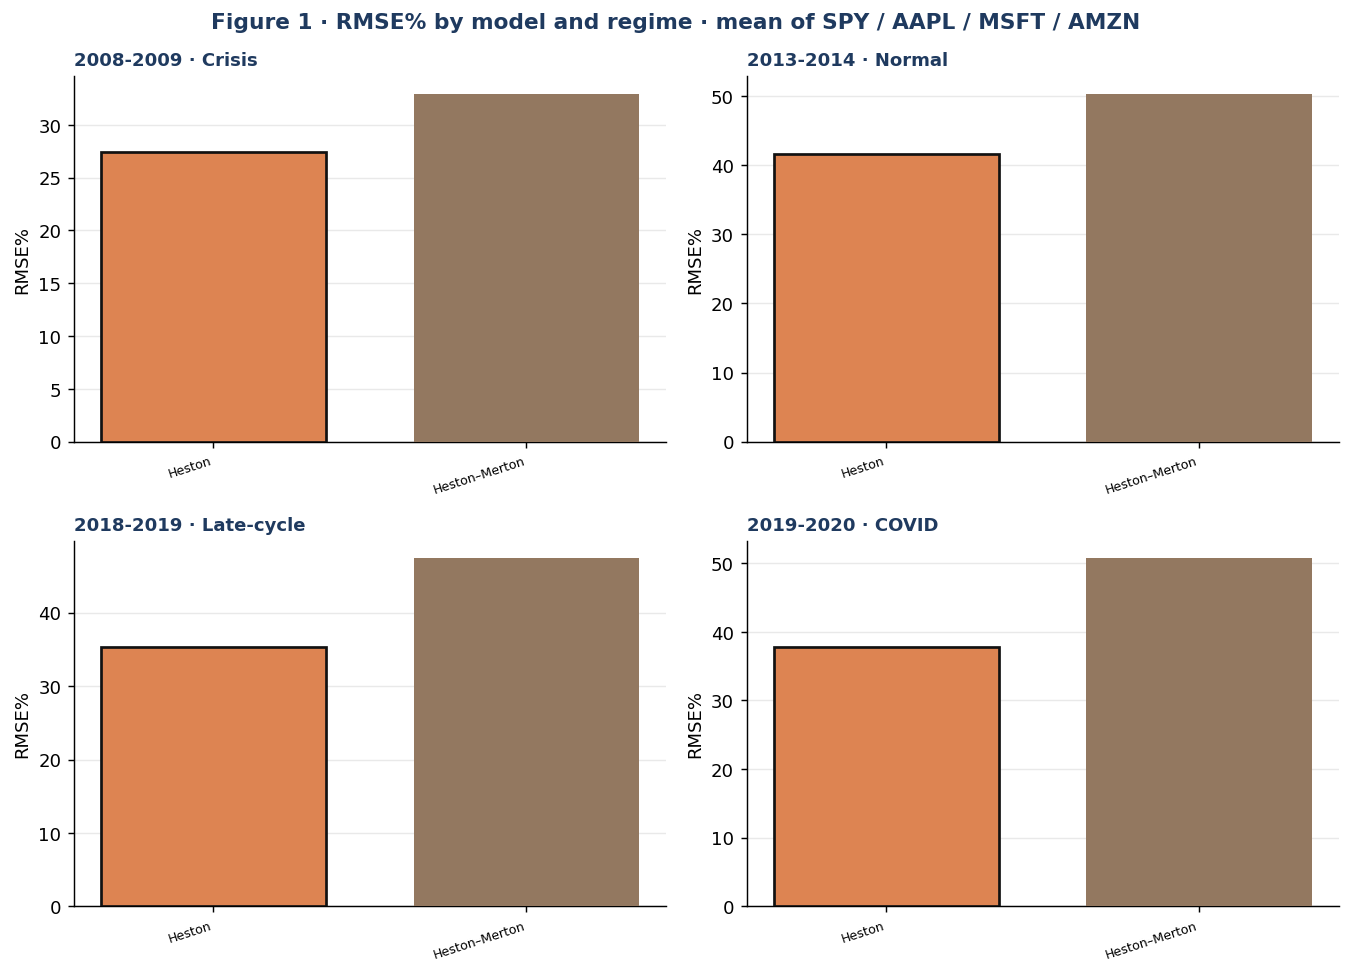

In [1]:
pass  # figure embedded from the same payload used for the PDF

### Figure 2 — RMSE% by company


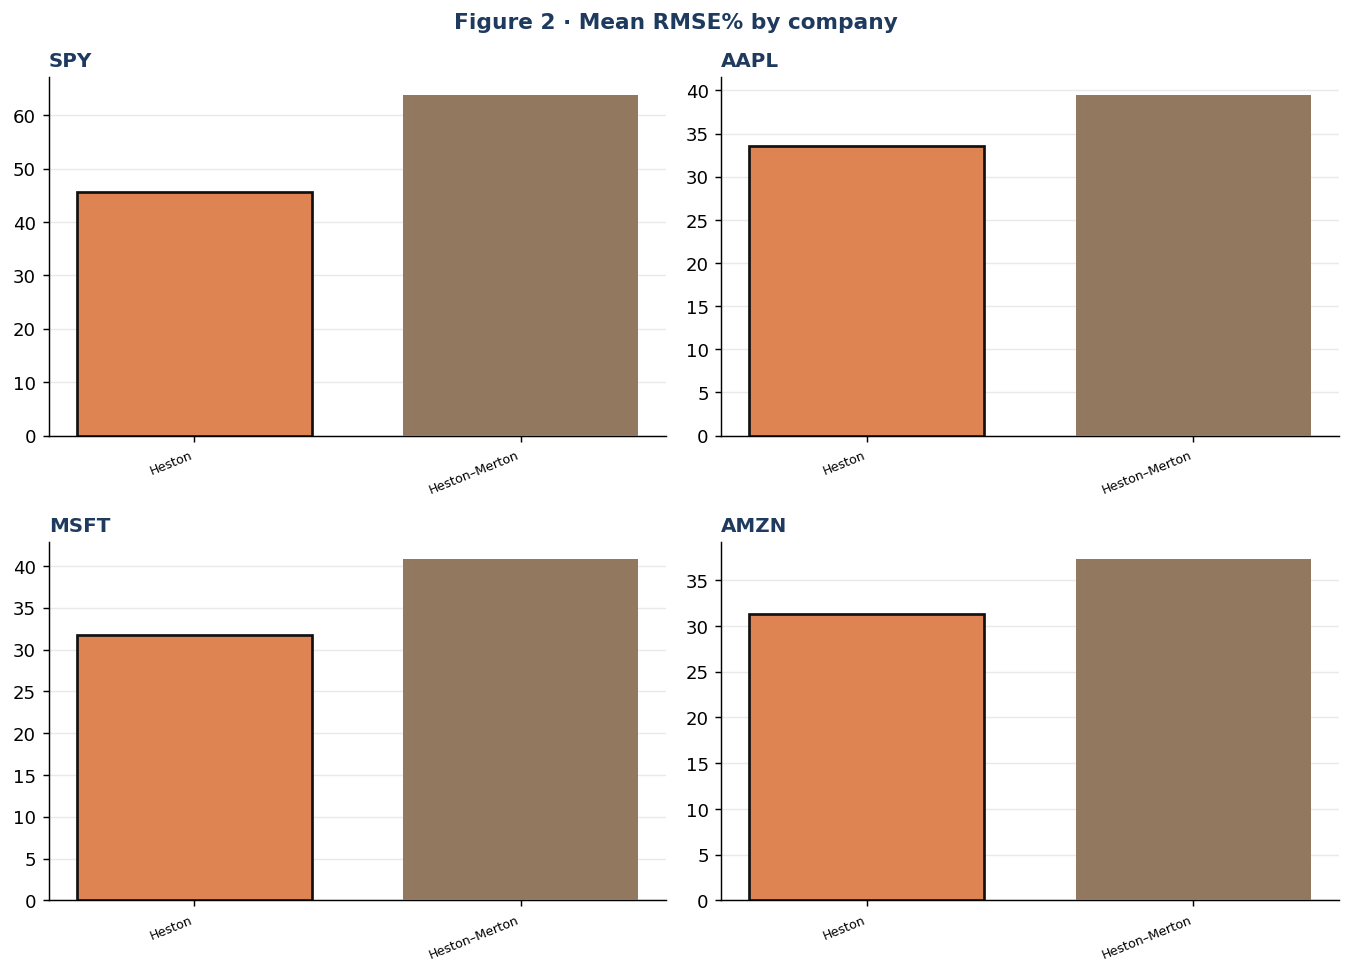

In [1]:
pass

### Figure 3 — Rank heatmap


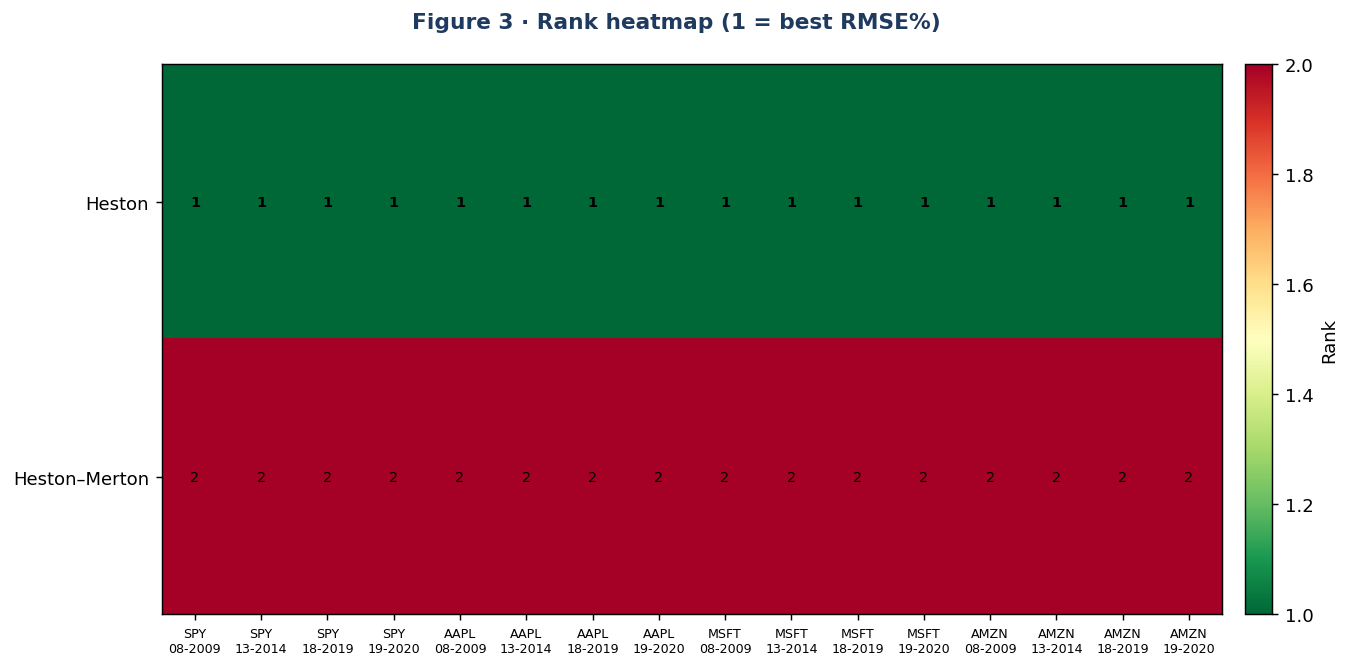

In [1]:
pass

## 5. Final analysis

- On mean percentage RMSE across the 16 company×regime cells, Heston is the best overall model (mean RMSE% = 35.56; 16 of 16 cells).

- Second overall is Heston–Merton (mean RMSE% = 45.37; 0 cells).

- The ranking is stable: Heston is best in every company and every regime.

- SPY: lowest mean RMSE% is Heston (45.67); wins 4 of 4 regimes.

- AAPL: lowest mean RMSE% is Heston (33.54); wins 4 of 4 regimes.

- MSFT: lowest mean RMSE% is Heston (31.73); wins 4 of 4 regimes.

- AMZN: lowest mean RMSE% is Heston (31.31); wins 4 of 4 regimes.

- 2008-2009 (Crisis): best mean RMSE% is Heston (27.39).

- 2013-2014 (Normal): best mean RMSE% is Heston (41.66).

- 2018-2019 (Late-cycle): best mean RMSE% is Heston (35.40).

- 2019-2020 (COVID): best mean RMSE% is Heston (37.80).

- No-jump models as a group have lower mean RMSE% (35.56) than the jump models in this report (45.37).

- For the overall winner (Heston), crisis RMSE% is 27.39 vs 41.66 in the 2014 normal year — absolute pricing error is regime-dependent even when the ranking is not.

- These conclusions are conditional on the V3 filters, 1.5-year monthly calibration, Monday ATM sample, LSM with 10,000 paths, and American-call quotes only. They are not a statement about European options or other tenors.


## 6. Reproducibility

This grouped report is assembled from the frozen 10,000-path cells. No new calibration or LSM.

```python
import run_v3_1p5y_10k_monthly_empirical_study_groups as groups
payload = groups.load_group('option_implied')
groups.write_group('option_implied')
```

The original six-model files `V3_1p5y_monthly_empirical_study.pdf` / `.ipynb` are not rewritten.
Partial results remain in `V4-Models_result/results/empirical_study_1p5y_monthly_10000/partial/`.
Shared contracts are frozen in `shared_contracts.json`.
